# Emotion Classification with RNNs, LSTMs & GRUs

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

## 1. Import Libraries
Import TensorFlow/Keras, and evaluation tools.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
train_df = pd.read_csv(r"dataset\train.csv")
test_df = pd.read_csv(r"dataset\test.csv")

In [3]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [4]:
test_df.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


In [5]:
train_text = train_df['text']
train_label = train_df['label']

test_text = test_df['text']
test_label = test_df['label']

In [6]:
label_names = sorted(train_df['label'].unique())

In [7]:
label_names

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

In [8]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [9]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [10]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Visualize class distribution across the 6 emotion labels.

In [11]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='str', name='label')

<Axes: xlabel='label', ylabel='count'>

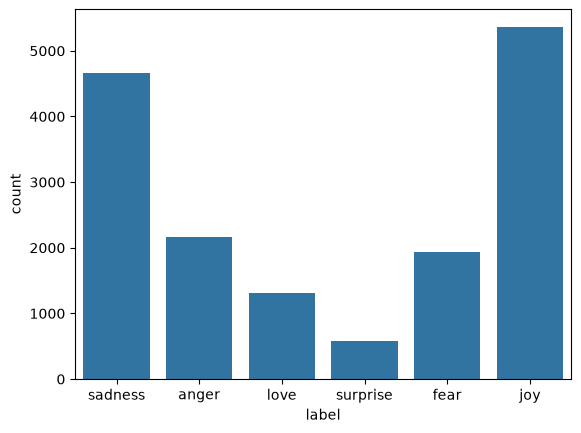

In [12]:
sns.countplot(x='label', data=df_train)

In [13]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## 4. Data Preprocessing - Using NLP
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
print(num_classes)


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

6
Vocabulary Size: 15213
Max Sentence Length: 50


## 5. Shared Training Utilities
Compute balanced class weights to handle dataset skew and setup early stopping.

In [15]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Phase 1 — Plain Foundational Models
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM

### 6.1 Model 2 — Standard LSTM
Plain stacked Long Short-Term Memory network.

In [22]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20


d:\CODING\DeepLearning\Collage_Project\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.1579 - loss: 1.7952 - val_accuracy: 0.2955 - val_loss: 1.7812
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.1514 - loss: 1.7936 - val_accuracy: 0.3445 - val_loss: 1.7817
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.1475 - loss: 1.7923 - val_accuracy: 0.0740 - val_loss: 1.8509
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.1641 - loss: 1.7480 - val_accuracy: 0.1800 - val_loss: 1.7476
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.3627 - loss: 1.3727 - val_accuracy: 0.5065 - val_loss: 1.1303
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.6503 - loss: 0.8283 - val_accuracy: 0.7290 - val_loss: 0.6560
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.8144 - loss: 0.5457 - val_accuracy: 0.8395 - val_loss: 0.5267
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.8898 - loss: 0.3625 - val_accurac

## 7. Final Predictions
Test the winning model on unseen sample sentences.

In [23]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(lstm_model.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: sadness
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: fear
